# Evaluation: Calibration & Lift Curves

This notebook extends the evaluation by adding these two missing components. No additional models are trained here; the three models developed in `04_modeling` are reused as they are.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import mord

In [9]:
train = pd.read_csv("../data/processed/telco_nps_train.csv")
test = pd.read_csv("../data/processed/telco_nps_test.csv")

target_order = ["Detractor", "Passive", "Promoter"]
target_map_num = {c: i for i, c in enumerate(target_order)}

X_train = train.drop(columns=["Customer ID", "NPS_Category"])
X_test = test.drop(columns=["Customer ID", "NPS_Category"])
y_train, y_test = train["NPS_Category"], test["NPS_Category"]
y_train_ord, y_test_ord = y_train.map(target_map_num), y_test.map(target_map_num)

cat_cols = X_train.select_dtypes(include="str").columns.tolist()
num_cols = X_train.select_dtypes(exclude="str").columns.tolist()

In [10]:
pipe_lr = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
pipe_lr.fit(X_train, y_train)
classes_lr = list(pipe_lr.named_steps["clf"].classes_)

X_train_gb, X_test_gb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_gb[c] = X_train_gb[c].astype("category")
    X_test_gb[c] = pd.Categorical(X_test_gb[c], categories=X_train_gb[c].cat.categories)

gb = HistGradientBoostingClassifier(
    categorical_features=[X_train_gb.columns.get_loc(c) for c in cat_cols],
    class_weight="balanced", random_state=42
)
gb.fit(X_train_gb, y_train)
classes_gb = list(gb.classes_)

prep_ord = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])
Xtr_o = prep_ord.fit_transform(X_train)
Xte_o = prep_ord.transform(X_test)
if hasattr(Xtr_o, "toarray"):
    Xtr_o, Xte_o = Xtr_o.toarray(), Xte_o.toarray()

sw = compute_sample_weight("balanced", y_train_ord)
ord_model = mord.LogisticAT(alpha=1.0)
ord_model.fit(Xtr_o, y_train_ord, sample_weight=sw)

/home/souleymane/telco-nps-prediction/venv/lib/python3.12/site-packages/mord/threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


,alpha,1.0
,verbose,0
,max_iter,1000
Name,Type,Value
classes_,"ndarray[int64](3,)","[0,1,2]"
coef_,"ndarray[float64](49,)","[-0.01, 0.01, 0. ,...,-0.15, 0.01, 0.08]"
n_class_,int64,np.int64(3)
theta_,"ndarray[float64](2,)","[-1.17, 0.58]"


The same code from `04_modeling.md` is reproduced here for notebook independence. The detailed hyperparameter choices and model family decisions are already explained there and are not repeated in this notebook.

## Extracting Detractor-Class Probabilities

We extract the predicted probability of being a Detractor using a one-vs-rest approach, as identifying this class is the main business priority.

In [11]:
p_det_lr = pipe_lr.predict_proba(X_test)[:, classes_lr.index("Detractor")]
p_det_gb = gb.predict_proba(X_test_gb)[:, classes_gb.index("Detractor")]
p_det_ord = ord_model.predict_proba(Xte_o)[:, 0]  # index 0 = Detractor

y_true_det = (y_test == "Detractor").astype(int)

## Calibration Curves

A well-calibrated probability should reflect the observed frequency: among customers receiving a predicted "70% Detractor probability", approximately 70% should actually belong to the Detractor class.

This matters if the retention team uses the score as a real risk estimate to prioritize actions (for example, deciding whether a customer should receive a phone call or an email), rather than using it only to rank customers.

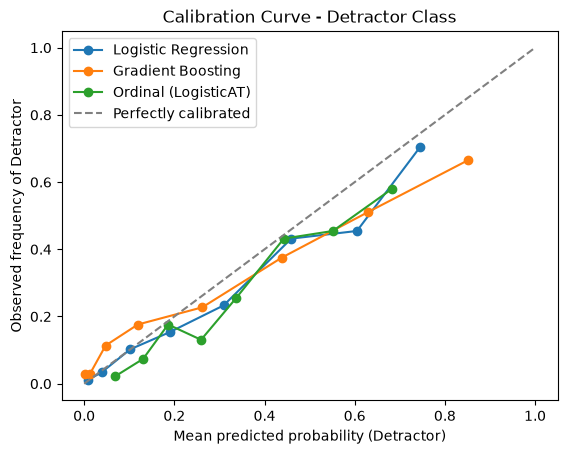

In [12]:
for name, p in [("Logistic Regression", p_det_lr), ("Gradient Boosting", p_det_gb), ("Ordinal (LogisticAT)", p_det_ord)]:
    frac_pos, mean_pred = calibration_curve(y_true_det, p, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability (Detractor)")
plt.ylabel("Observed frequency of Detractor")
plt.title("Calibration Curve - Detractor Class")
plt.legend()
plt.show()

In [13]:
for name, p in [("LR", p_det_lr), ("GB", p_det_gb), ("ORD", p_det_ord)]:
    print(name, brier_score_loss(y_true_det, p))

LR 0.14574940308747056
GB 0.15432182380727597
ORD 0.1667270574065591


Le Brier score (plus bas = mieux calibré) place la régression logistique en tête, suivie du gradient boosting, puis du modèle ordinal. C'est un résultat qui **nuance la conclusion de `04_modeling`** : le modèle ordinal avait été retenu pour son faible taux d'erreurs extrêmes (Détracteur classé Promoteur), mais ses probabilités individuelles sont les moins fiables des trois. Les deux critères ne racontent pas la même histoire, et c'est un vrai compromis à trancher, pas un oubli à corriger.

## Lift Curve : Detractor Class

Le lift curve répond à une question directement opérationnelle : si l'équipe rétention ne peut appeler que X% de la base (contrainte de capacité), quelle proportion des vrais détracteurs capture-t-on en ciblant les clients avec le score de risque le plus élevé ?

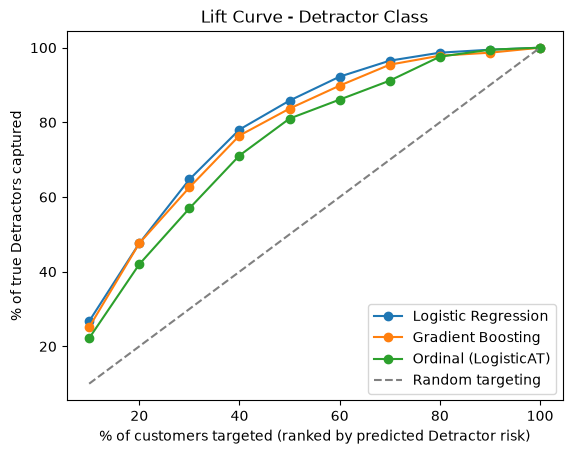

In [14]:
def lift_curve(y_true, p, n_deciles=10):
    order = np.argsort(-p)
    y_sorted = y_true[order]
    n = len(y_true)
    deciles = []
    for i in range(1, n_deciles + 1):
        k = int(n * i / n_deciles)
        capture_rate = y_sorted[:k].sum() / y_true.sum()
        deciles.append(capture_rate)
    return deciles

x = [i*10 for i in range(1, 11)]
for name, p in [("Logistic Regression", p_det_lr), ("Gradient Boosting", p_det_gb), ("Ordinal (LogisticAT)", p_det_ord)]:
    deciles = lift_curve(y_true_det.values, p)
    plt.plot(x, [d*100 for d in deciles], marker="o", label=name)
plt.plot(x, x, linestyle="--", color="gray", label="Random targeting")
plt.xlabel("% of customers targeted (ranked by predicted Detractor risk)")
plt.ylabel("% of true Detractors captured")
plt.title("Lift Curve - Detractor Class")
plt.legend()
plt.show()

Logistic Regression is also slightly ahead of the other two models in this analysis, which is consistent with its better Brier score: it provides more reliable probability estimates while maintaining strong risk ranking performance.

## Reconciling with the Model Selection in 04_modeling

`04_modeling` selected the **Ordinal Model** as the reference model, based on its Quadratic Weighted Kappa score and its lowest rate of extreme errors.

This additional evaluation shows that **there is no universally best model**. The most appropriate choice depends on how the retention team intends to use the model predictions in practice.

| Intended Use Case | Recommended Model | Justification |
|---|---|---|
| **Strict categorical decision** (the model assigns each customer to Detractor/Passive/Promoter, with a different action for each category) | **Ordinal Model (LogisticAT)** | Minimizes severe errors (a Detractor classified as Promoter becomes a completely hidden risk for the retention team). |
| **Ranked risk targeting list** (the retention team contacts the X% highest-risk customers, depending on daily capacity) | **Logistic Regression** | Provides better calibration (Brier score) and the best lift performance across all tested thresholds. |

**Updated recommendation:** based on the business objective described in the project ("prioritize outreach towards predicted Detractors... simulate the expected NPS of the silent 85%"), the most likely use case is a ranked list of customers by risk rather than a strict categorical decision.

A retention team with limited calling capacity will typically want to target "the X% highest-risk customers" instead of contacting all customers predicted as Detractors.

In this context, **Logistic Regression becomes the most defensible production candidate**, despite having a higher extreme error rate than the Ordinal Model. This limitation is less critical when the final decision relies on a continuous risk ranking rather than a fixed predicted category.

This highlights an important point for the final write-up: model selection is not only about metrics. It fundamentally depends on how the final product will be designed and used (section 4.8, interface). The final model choice should be aligned with the business team before selecting a single "winning" model.

## Summary: Key Findings

- **Calibration**: Logistic Regression is the best-calibrated model among the three (Brier score: 0.146), followed by Gradient Boosting (0.154) and the Ordinal Model (0.167).

- **Lift**: Targeting the 20% highest-risk customers captures 42–48% of true Detractors depending on the model (compared to 20% with random targeting). This represents a concrete and significant business improvement, regardless of the selected model.

- **Key trade-off revealed**: the Ordinal Model (selected in `04_modeling` because of its lower extreme error rate) is not the best model in terms of calibration or lift. The final choice depends on the product usage scenario (categorical decision vs. continuous risk ranking), not on a single metric.

## Conclusion

This evaluation highlights a trade-off between ordinal consistency (Ordinal Model) and probability quality (Logistic Regression).

Instead of forcing a single choice too early, this notebook explicitly documents the trade-off and proposes a clear decision criterion based on the intended product usage. The final choice will be made during the interface design phase in `07_interface`.

Next step: `06_interpretability` (SHAP analysis and Detractor drivers by segment). This analysis will also help inform the final model choice, as a model with business-actionable drivers (e.g., `Contract`, `OnlineSecurity`) provides additional value beyond raw predictive performance.